<h1 style="text-align: center;">ANÁLISIS Y PROCESAMIENTO DE SEÑALES</h1>

<center>
    
### 1er cuatrimestre 2026
</center>

<p style="text-align: center;">Muñoz Jazmín Ayelén</p>

<h3 style="text-align;">INTRODUCCIÓN</h3>

En esta tarea semanal se estudia un fenómeno fundamental del análisis espectral discreto, el efecto de desparramo espectral, también mencionado por el docente como "spectral leakage". Es un fenómeno que aparece al calcular la DFT - Transformada Discreta de Fourier - de señales que parecen ser  perfectamente periódicas tal como la  senoidal previamente estudiada en reiteradas ocasiones.

El objetivo del experimento consiste en analizar cómo pequeñas variaciones de la frecuencia, de una señal afectan su espectro en el dominio de la frecuencia y el impacto del mismo en la estimación de la densidad espectral de potencia.

<h4 style="text-align;">1. Transformada Discreta de Fourier (DFT)</h4>

La DTF se encuentra directamente relacionada con la Transformada de Fourier en Tiempo Discreto -DTFT-. 
La DTFT describe el contenido en frecuencia de una señal discreta en el tiempo de manera continua, es decir, para cualquier valor de frecuencia, la DFT solo evalúa dicha información en un conjunto finito de frecuencias de carácter discreto.

Es decir que, la DFT puede interpretarse como un muestreo de la DTFT, dichos puntos de muestreo están determinados por la cantidad de muestras N, y corresponden a frecuencias que están equiespaciadas.

En la práctica no se trabaja con señales infinitas, sino con una cantidad finita de muestras, es decir que la señal original se debe recortarr con una ventana, en este caso, de caracter rectangular.
Este ventaneo, producirá un cambio en frecuencia, ya que multitplicar en tiempo consiste en convolucionar en frecuencia,  entre el espectro ideal de la señal que en caso de ser un seno, es dos deltas y el espectro de la ventana, que suele ser una sinc.

Cuando la frecuencia de la señal no coincide con los puntos donde la DFT la evalúa, es decir en los bins, la energía no queda concentrada en un único punto, sino que se distribuye entre varios bins vecinos. 

Las frecuencias discretas se hallan determinadas por la siguiente expresión: 

\begin{equation}
f_k = k \cdot \Delta f = k \cdot \frac{f_s}{N}
\end{equation}

Donde:

- $f_s$ es la frecuencia de muestreo.
- $N$ es la cantidad de muestras.
- $\Delta f$ es la resolución espectral.
- $k$ es el índice de frecuencia que corresponde a un bin.

Si una señal senoidal tiene una frecuencia exactamente igual a uno de los bins de la DFT, se dice que la señal está sincronizda con la DFT y en este caso, toda la energía de la señal se concentra en un único bin, sino coincide, la señal está desincronizada.

<h4 style="text-align;">2. Desparrame espectral (leakage)</h4>

La DFT asume siempre que la señal es periódica, por lo que si se toma un ciclo incompleto de la señal, esta se "pega" mal, y se producen saltos de discontinuidades, que resultan difíciles de representar, requieren de un gran cambio de frecuencias, la energía se distribuye entre múltiples bins y aparecen los lóbulos secundarios de la sinc, que antes coincidían con sus ceros, en el espectro.

<h4 style="text-align;">3. Zero Padding</h4>

El zero padding es una técnica que consiste en agregar ceros al final de la señal antes de calcular la DFT. No agrega información nueva, sino que aumenta la cantidad de puntos en el eje de frecuencias, mejorando la visualización del espectro mediante la interpolación.
Permite observar con mayor detalle el desparramo espectral, cabe destacar que no mejora la resolución real, sino que "suaviza" la representación.

<h3 style="text-align;">RESOLUCIÓN DE LAS CONSIGNAS</h3>

Se tine una senoidal de frecuencia$$f_0 = k_0 \cdot \frac{f_S}{N} = k_0 \cdot \Delta f$$ con potencia normalizada, es decir, energía (o varianza) unitaria.

Se pide:   a) Sea$$k_0 = \frac{N}{4}, \quad \frac{N}{4} + 0.25, \quad \frac{N}{4} + 0.5$$Notar que a cada senoidal se le agrega una pequeña desintonía respecto a $\Delta f$. Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

<h4 style="text-align;">A. CREO A FUNCIÓN</h4>

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.linspace(0, (nn-1)*ts, nn)
    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    return tt, xx

fs = 1000
N = 100 
vmax = np.sqrt(2) #Normalizo para tener bien la potencia unitaria. 

<h4 style="text-align;">B. LLAMO A LA FUNCIÓN PARA LOS TRES CASOS.</h4>

In [20]:
# PRIMER CASO CON K=N/4 ES DECIR SINTONIZADO.

k1 = N/4
f01 = k1 * (fs/N)
tt1, xx1 = mi_funcion_sen(vmax, 0, f01, 0, N, fs)
XX1 = np.fft.fft(xx1) / N
freqs = np.fft.fftfreq(N, 1/fs)
pos_freqs = freqs[:N//2]
psd1 = 10 * np.log10(2 * np.abs(XX1[:N//2])**2)


# SEGUNDO CASO CON K=N/4 + 0.25 UN CORRIMIENTO QUE LO HACE CAER ENTRE DOS BINS.

k2 = N/4 + 0.25
f02 = k2 * (fs/N)
tt2, xx2 = mi_funcion_sen(vmax, 0, f02, 0, N, fs)
XX2 = np.fft.fft(xx2) / N
psd2 = 10 * np.log10(2 * np.abs(XX2[:N//2])**2)



# TERCER CASO CON K=N/4 + 0.50 UN CORRIMIENTO QUE LO HACE CAER EN LA MITAD DE LOS DOS BINS. 


k3 = N/4 + 0.5
f03 = k3 * (fs/N)
tt3, xx3 = mi_funcion_sen(vmax, 0, f03, 0, N, fs)
XX3 = np.fft.fft(xx3) / N
psd3 = 10 * np.log10(2 * np.abs(XX3[:N//2])**2)


**<h4 style="text-align;">C. HAGO LOS GRÁFICOS PARA LOS TRES CASOS</h4>**

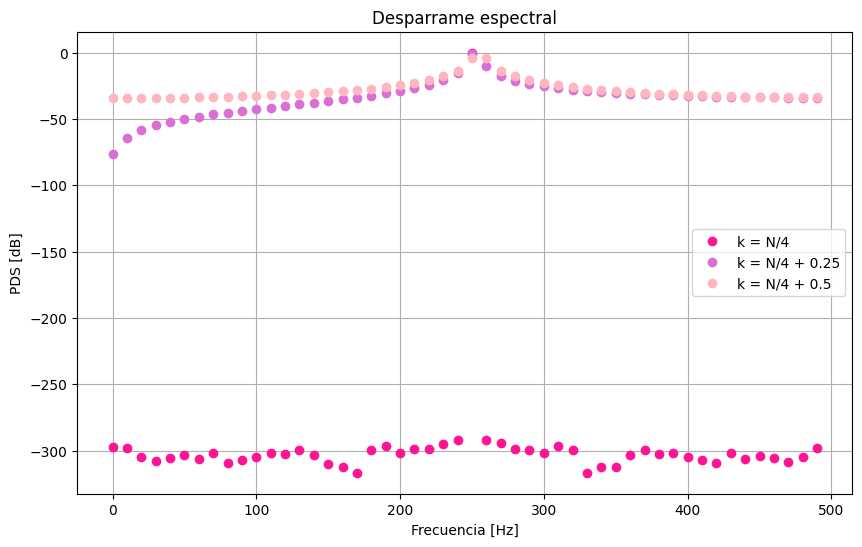

In [24]:

plt.figure(figsize=(10,6))
plt.plot(pos_freqs, psd1, 'o', label='k = N/4', color='deeppink')
plt.plot(pos_freqs, psd2, 'o', label='k = N/4 + 0.25',color='orchid')
plt.plot(pos_freqs, psd3, 'o', label='k = N/4 + 0.5',color='lightpink')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PDS [dB]')
plt.title('Desparrame espectral')
plt.legend()
plt.grid()

plt.show()

**<h5 style="text-align;">CASO 1: K= N/4 </h5>**

En este caso, la frecuencia de la señal coincide exactamente con un bin de la DFT. Es por ello que se observa un pico bien definido y concentrado en una única frecuencia, ya que la energía está localizada en un solo bin.

Esto representa el caso ideal, donde la señal está perfectamente representada en la grilla de la DFT.

El pico principal cae justo en un bin, y los lóbulos laterales de la sinc caen exactamente sobre los otros bins de la grilla, donde sus valores son nulos, o sea que coinciden en los cruces por cero de la sinc.

Esto tiene sentido ya que, al ser N=100, se cumple que N/4=25, que es un número entero. Por lo tanto, la frecuencia coincide exactamente con un índice de bin de la DFT.

**<h5 style="text-align;">CASO 2: K= N/4 + 0.25 </h5>**

Al introducir este desplazamiento, la frecuencia ya no coincide con un bin de la grilla, sino que cae entre un punto intermedio. En el dominio del tiempo, significa que la señal presenta discontinuidades en los bordes de la ventana "se pega mal, por no ser periódica" 

Como consecuencia en el espectro, es decir en el dominio de la frecuencia, ya nos e evalúa la función en los cruces por cero, y es por ello que aparece el desparramo espectral , la energía se dispersa hacia los bins vecinos de forma asimétrica, permitiendo percibir los lóbulos secundarios de la sinc. 


**<h5 style="text-align;">CASO 3: K= N/4 + 0.50 </h5>**

En este caso, la frecuencia de la señal se encuentra exactamente en la mitad entre dos bins consecutivos, representa el peor caso teórico de desparrame espectral de la DFT.  El desparramo espectral está en su expresión más severa, se distribuye simétricamente, como se puede observar en el gráfico a diferencia del caso 2, es decir que la energía del lóbulo principal se reparte en partes iguales entre los dos bins vecinos, sufriendo una gran disminución de la máxima amplitud. Busqué información al respecto, se denomina "scalloping loss" o "pérdida por festoneado"  
Los bins del resto del espectro se muestran en los picos relativos de los lóbulos secundarios, ya no en sus ceros o cerca de ellos como lo era en el caso anterior, esto provoca que se eleve el piso de ruido. 

Como conclusión general, se puede decir que el desparrame espectral ocurre cuando la frecuencia de la señal no coincide con la grilla de la DFT, como consecuencia, la energía deja de concentrarse en un único bin y se distribuye entre varios.
Este efecto se debe a que la señal no es periódica dentro de la ventana de observación, y en frecuencia aparece el espectro de la sinc. 

b) Verificar la potencia unitaria de cada PSD, puede usar la identidad de Parseval. En base a la teoría estudiada. Discuta la razón por la cual una señal senoidal tiene un espectro tan diferente respecto a otra de muy pocos Hertz de diferencia. 

In [42]:
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs #Calculo el tiempo entre cada muestra.
    tt = np.linspace(0, (nn-1)*ts, nn) #Creo el vector de ceros que arranco en 0 y tiene nn muestras. 
    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    return tt, xx

fs = 1000
N = 100
vmax = np.sqrt(2)

# HAGO EL CASO NÚMERO 1.

k1 = N/4
f01 = k1 * (fs/N) #Convirtto la frecuencia en un múltiplo de bin* resolución espectral. 
t1, x1 = mi_funcion_sen(vmax, 0, f01, 0, N, fs)

X1 = np.fft.fft(x1) / N #Calculo la fft

Etiempo1 = np.sum(np.abs(x1)**2) / N #Acá calculo la potencia en el tiempo, sumo al cuadrado todas las muestras, que es la energía total, y luego lo
#divido por N para obtener el valor promediado, o sea la poitencia media. 
Efreq1 = np.sum(np.abs(X1)**2) #Hago Parsrval, sumo el módulo al cuadrado de todos los bins de frecuencia, 
#o sea la suma de las potencias de todas las componentes del espectro. 


#  HAGO EL CASO NÚMERO  2. 

k2 = N/4 + 0.25
f02 = k2 * (fs/N)
t2, x2 = mi_funcion_sen(vmax, 0, f02, 0, N, fs)

X2 = np.fft.fft(x2) / N

E_time2 = np.sum(np.abs(x2)**2) / N
E_freq2 = np.sum(np.abs(X2)**2)

# HAGO EL CASO NÚMERO  3. 
k3 = N/4 + 0.5
f03 = k3 * (fs/N)
t3, x3 = mi_funcion_sen(vmax, 0, f03, 0, N, fs)

X3 = np.fft.fft(x3) / N

Etiempo3 = np.sum(np.abs(x3)**2) / N
Efreq3 = np.sum(np.abs(X3)**2)

# IMPRIMO LOS RESULTADOS.

print("CASO 1 (k = N/4)")
print("Potencia mieda del Caso 1 en el espectro del tiempo :", Etiempo1)
print("Potencia media del Caso 1 en el espectro de la frecuencia:", Efreq1)
print("-" * 80) #Vi que se puede usar esto para separar. 

print("\nCASO 2 (k = N/4 + 0.25)") #Me quedaba todo junto, así que busqué cómo separarlo, y me saltó que con el \n me da un salto de línea. 
print("Potencia mieda del Caso 2 en el espectro del tiempo: ", E_time2)
print("Potencia media del Caso 2 en el espectro de la frecuencia::", E_freq2)

print("-" * 80)

print("\nCASO 3 (k = N/4 + 0.5)")
print("Potencia mieda del Caso 3 en el espectro del tiempo:", Etiempo3)
print("Potencia media del Caso 3 en el espectro de la frecuencia::", Efreq3)

CASO 1 (k = N/4)
Potencia mieda del Caso 1 en el espectro del tiempo : 1.0000000000000002
Potencia media del Caso 1 en el espectro de la frecuencia: 1.0000000000000002
--------------------------------------------------------------------------------

CASO 2 (k = N/4 + 0.25)
Potencia mieda del Caso 2 en el espectro del tiempo:  0.9900000000000003
Potencia media del Caso 2 en el espectro de la frecuencia:: 0.9900000000000002
--------------------------------------------------------------------------------

CASO 3 (k = N/4 + 0.5)
Potencia mieda del Caso 3 en el espectro del tiempo: 0.9999999999999996
Potencia media del Caso 3 en el espectro de la frecuencia:: 0.9999999999999996


- VERIFICACIÓN DE LA POTENCIA Y TEOREMA DE PARSEVAL.

Al calcular la potencia media en los tres casos pedidos, se puede comprobar que los valores son prácticamente unos, lo que coincide con la potencia unitaria, tanto el dominio del tiempo como en el de la frecuencia. 

El Teorema de Parseval, que cuando se aplica a la potencia, se denomina relación de Plancherel o Rayleigh que sostiene que la potencia total calculada mirando la onda en el tiempo es exactamente igual a la suma de las potencias de cada una de sus componentes en el dominio de las frecuencias.

Se puede afirmar que se cumple el Teorema de Parseval y que además, el desparramo espectral produce un efecto en la forma en la que se distribuye la energía en el gráfico, pero la cantidad de señal que hay, se conserva en ambos dominios. 

- ANÁLISIS DEL SISTEMA FRENTE A PEQUEÑAS DESINTONÍAS. 

La consigna pedía discutir la razón por la cual una señal senoidal tiene un espectro tan diferente respecto a otra de muy pocos Hertz de diferencia, esto puede explicarse debido a como funciona la DFT, esta asume que la señal, y la ventana temporal, se repite infinitamente en el tiempo, pegando, como ya se dijo al principio, un bloque tras otro, si la frecuecnia de la señal coincide con la grilla de la DFT , cuando estos bloques se repiten, el final de uno de esos bloques de información se "pega" bien con el principio del siguiente, dando una onda suave y continua. 


Sin embargo, si se desplaza la frecuencia unos pocos Hertz, de modo tal que la onda ya no entra justa, cuando se peguen los bloques, se produce una discontinuidad abrupta y para que se pueda representar, se requieren muchos componentes de frecuencia adicionales con diferentes amplitudes. 

c) Repetir el experimento mediante la técnica de zero padding. Dicha técnica consiste en agregar ceros al final de la señal para aumentar Δf
 de forma ficticia. Probar agregando un vector de 9*N ceros al final. Discuta los resultados obtenidos.

El Zero Padding, como ya se mencionó en la introducción, funciona como una lupa al espectro, no se agrega información nueva sino que al rellenar con ceros se obliga a calcular puntos intermedios, lo que permite ver la forma real y continua del espectro, en este caso por ser ventana rectangular, una sinc. 

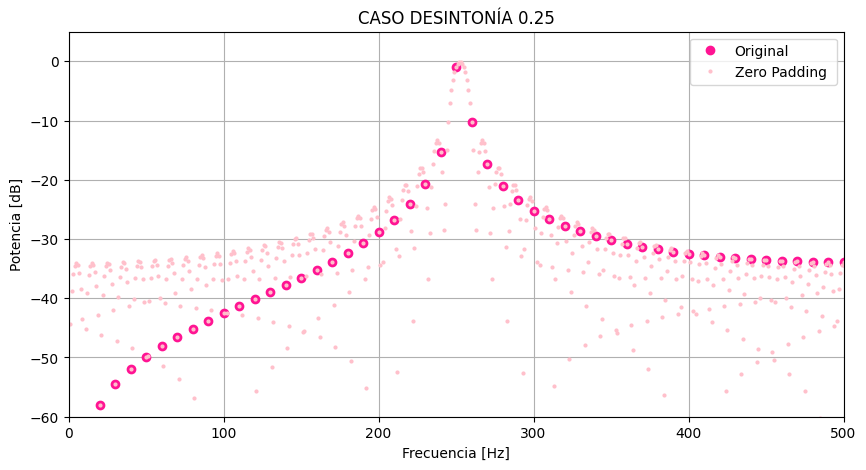

In [40]:
# Defino los parámetros de mi señal. 
k = N/4 + 0.25 # Desintonía de 0.25 
f0 = k * (fs/N) 

tt, xx = mi_funcion_sen(vmax, 0, f0, 0, N, fs)

# HAGO LO DE ZERO PADDING # 
ceros = np.zeros_like(xx) 
cantidaddepad = 9
zeros_zp = np.tile(ceros, cantidaddepad) 
xpadeada = np.concatenate((xx, zeros_zp), axis=0) 

# HAGO LA FFT (Divido siempre por N = 100)
X = np.fft.fft(xx) / N
Xpadeada = np.fft.fft(xpadeada) / N 

# CALCULO LA PSD Y PASO A dB
# Multiplico por 2 para juntar la energía
psd_lineal = (np.abs(X)**2) * 2
psd_zp_lineal = (np.abs(Xpadeada)**2) * 2

# Paso a dB. Le sumo 1e-12 para que el logaritmo no dé error si hay un 0 exacto.
psd_db = 10 * np.log10(psd_lineal + 1e-12)
psd_zp_db = 10 * np.log10(psd_zp_lineal + 1e-12)

# CREO LA FRECUENCIA A MANO 
f_manual = np.arange(0, N) * (fs / N) 

N_total = len(xpadeada)
f_zp_manual = np.arange(0, N_total) * (fs / N_total)

# HAGO EL GRAFICO 
plt.figure(figsize=(10,5))

# Ploteo usando las variables en dB
plt.plot(f_manual, psd_db, 'o', color='deeppink', label='Original')
plt.plot(f_zp_manual, psd_zp_db, 'o', markersize=2, linewidth=1.5, color='pink', label='Zero Padding ') 

plt.grid(True)
plt.title('CASO DESINTONÍA 0.25')
plt.xlim(0, fs/2) # Solo hasta fs/2 -Nyquist-
plt.ylim(-60, 5)  # Limito el eje Y para ver bien desde 0 dB hasta el piso de los lóbulos
plt.ylabel('Potencia [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.legend()
plt.show()


En este caso, se tiene una desintonía leve, todos los puntos se corrieron hacia la derecha, se está muestreando en lugares no óptimos, el punto más alto ya no coincide con el pico máximo de la campana, sino que cae un poco más abajo, este fenómeno es lo que se había mencionado antes, "scalloping loss" , el resto de puntos ya no cae en los ceros, se puede observar el desparramo espectral asimétrico.

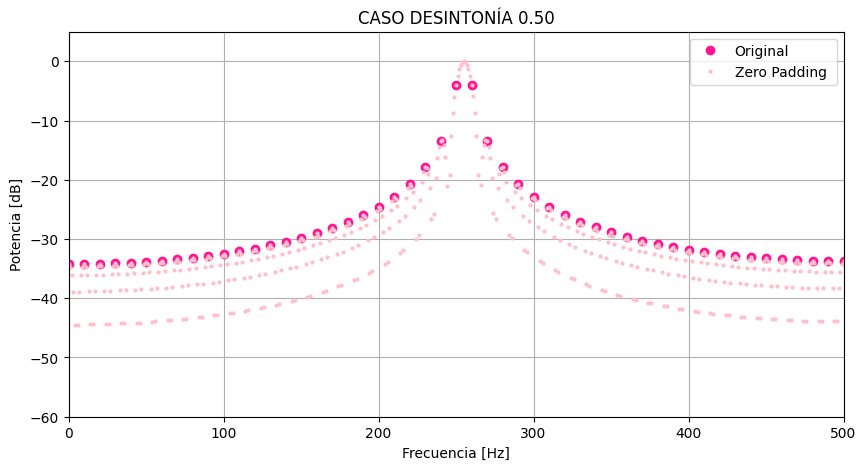

In [39]:
# Defino los parámetros de mi señal. 
k = N/4 + 0.50 # Desintonía de 0.50 
f0 = k * (fs/N) 

tt, xx = mi_funcion_sen(vmax, 0, f0, 0, N, fs)

# HAGO LO DE ZERO PADDING # 
ceros = np.zeros_like(xx) 
cantidaddepad = 9
zeros_zp = np.tile(ceros, cantidaddepad) 
xpadeada = np.concatenate((xx, zeros_zp), axis=0) 

# HAGO LA FFT (Divido siempre por N = 100)
X = np.fft.fft(xx) / N
Xpadeada = np.fft.fft(xpadeada) / N 

# CALCULO LA PSD Y PASO A dB
# Multiplico por 2 para juntar la energía
psd_lineal = (np.abs(X)**2) * 2
psd_zp_lineal = (np.abs(Xpadeada)**2) * 2

# Paso a dB. Le sumo 1e-12 para que el logaritmo no dé error si hay un 0 exacto.
psd_db = 10 * np.log10(psd_lineal + 1e-12)
psd_zp_db = 10 * np.log10(psd_zp_lineal + 1e-12)

# CREO LA FRECUENCIA A MANO 
f_manual = np.arange(0, N) * (fs / N) 

N_total = len(xpadeada)
f_zp_manual = np.arange(0, N_total) * (fs / N_total)

# HAGO EL GRAFICO 
plt.figure(figsize=(10,5))

# Ploteo usando las variables en dB
plt.plot(f_manual, psd_db, 'o', color='deeppink', label='Original')
plt.plot(f_zp_manual, psd_zp_db, 'o', markersize=2, linewidth=1.5, color='pink', label='Zero Padding ') 

plt.grid(True)
plt.title('CASO DESINTONÍA 0.50')
plt.xlim(0, fs/2) # Solo hasta fs/2 -Nyquist-
plt.ylim(-60, 5)  # Limito el eje Y para ver bien desde 0 dB hasta el piso de los lóbulos
plt.ylabel('Potencia [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.legend()
plt.show()



En este, se tiene el peor caso teórico, la frecuencia real de la señal queda exactamente en la mitad de camino entre dos bins de la grilla. La FFT  no logre capturar el lóbulo principal, y en su lugar, toma dos muestras simétricas a los costados del pico, ambas sufriendo la máxima atenuación posible en su amplitud, mientras que el resto de los puntos caen en los máximos relativos de los lóbulos secundarios de la sinc, lo que levanta todo el piso de rudio tal como se puede ver en el gráfico, evidenciando un gran desparramo espectral súmamente simétrico.

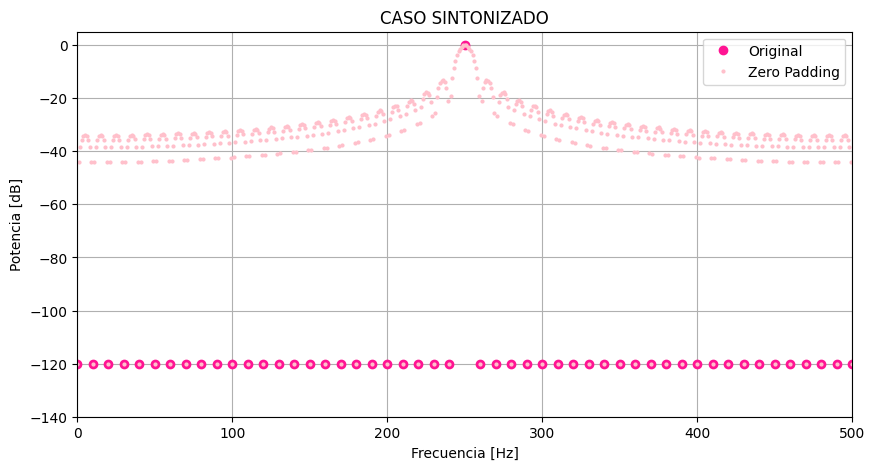

In [48]:
# Defino los parámetros de mi señal. 
k = N/4 # sinton
f0 = k * (fs/N) 

tt, xx = mi_funcion_sen(vmax, 0, f0, 0, N, fs)

# HAGO LO DE ZERO PADDING # 
ceros = np.zeros_like(xx) 
cantidaddepad = 9
zeros_zp = np.tile(ceros, cantidaddepad) 
xpadeada = np.concatenate((xx, zeros_zp), axis=0) 

# HAGO LA FFT (Divido siempre por N = 100)
X = np.fft.fft(xx) / N
Xpadeada = np.fft.fft(xpadeada) / N 

# CALCULO LA PSD Y PASO A dB
# Multiplico por 2 para juntar la energía
psd_lineal = (np.abs(X)**2) * 2
psd_zp_lineal = (np.abs(Xpadeada)**2) * 2

# Paso a dB. y le agrego + 1e-12 para poder visualizar los puntos de abajo, sino como me da el límite -inf, ni los grafica.
psd_db = 10 * np.log10(psd_lineal+ 1e-12)
psd_zp_db = 10 * np.log10(psd_zp_lineal+ 1e-12)

# CREO LA FRECUENCIA A MANO 
f_manual = np.arange(0, N) * (fs / N) 

N_total = len(xpadeada)
f_zp_manual = np.arange(0, N_total) * (fs / N_total)

# HAGO EL GRAFICO 
plt.figure(figsize=(10,5))

# Ploteo usando las variables en dB
plt.plot(f_manual, psd_db, 'o', color='deeppink', label='Original')
plt.plot(f_zp_manual, psd_zp_db, 'o', markersize=2, linewidth=1.5, color='pink', label='Zero Padding') 

plt.grid(True)
plt.title('CASO SINTONIZADO')
plt.xlim(0, fs/2) # Solo hasta fs/2 -Nyquist-
plt.ylim(-140, 5)  # Limito el eje Y para ver bien desde 0 dB hasta el piso de los lóbulos
plt.ylabel('Potencia [dB]')
plt.xlabel('Frecuencia [Hz]')
plt.legend()
plt.show()



En este, el gráfico muestra el caso ideal, la curva padeada dibuja la forma real de la energía, se ve un lóbulo principal en el centro y los lóbulos secundarios que rebotan hacia los costados. El punto máximo cae exactamente en el pico del lóbulo principal de la sinc, y los demás caen en los cruces por cero de la función, es por ello que no se ve el desparramo. En este caso, los demás puntos no se ven porque 

Por último, cabe destacar que la sinc que se visualiza gracias al desparramo espectral, no "aparece" sino que se vuelve visible, ya que la grilla de la DFT deja de coincidir con los cruces por cero de la función, que en realidad, siempre estuvo ahí, es producto de la convolución en frecuencia de la señal y la cajita, es decir la ventana rectangular que se toma, cuando no se elige una ventana en sí. Existen otros tipos de ventanas, que permiten disminuir los efectos del desparramo espectral, atenuando los extremos para que no se produzcan las discontinuidades, esto se analizó analíticamente en las guías subidas por Joaquín. 